# Task 3 - Identify Urban Sound Types

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/datasets/UrbanSound8K"
print(os.listdir(DATASET_PATH))


['UrbanSound8K.csv', 'fold5', 'fold6', 'fold10', 'fold2', 'fold8', 'fold9', 'fold7', 'fold4', 'fold3', 'fold1']


In [ ]:
!pip install librosa tqdm xgboost


## 1. Load Data

In [ ]:
import pandas as pd

w2q\acsv_path = os.path.join(DATASET_PATH, "UrbanSound8K.csv")
metadata = pd.read_csv(csv_path)

metadata.head(), metadata["class"].value_counts()


(      slice_file_name    fsID  start        end  salience  fold  classID  \
 0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
 1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
 2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
 3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
 4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   
 
               class  
 0          dog_bark  
 1  children_playing  
 2  children_playing  
 3  children_playing  
 4  children_playing  ,
 class
 dog_bark            1000
 children_playing    1000
 air_conditioner     1000
 street_music        1000
 jackhammer          1000
 engine_idling       1000
 drilling            1000
 siren                929
 car_horn             429
 gun_shot             374
 Name: count, dtype: int64)

## 2. Feature Extraction(MFCC)

In [ ]:
import numpy as np
import librosa
from tqdm import tqdm

def extract_features(row):
    file_path = os.path.join(
        DATASET_PATH,
        f"fold{row['fold']}",
        row["slice_file_name"]
    )
    try:
        audio, sr = librosa.load(file_path, sr=None)
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfccs_mean = np.mean(mfccs.T, axis=0)
        return mfccs_mean
    except Exception as e:
        return None

subset = metadata[metadata["fold"].isin([1, 2])].reset_index(drop=True)

features = []
labels = []

for _, row in tqdm(subset.iterrows(), total=len(subset)):
    mfcc_feat = extract_features(row)
    if mfcc_feat is not None:
        features.append(mfcc_feat)
        labels.append(row["classID"])

X = np.array(features)
y = np.array(labels)

X.shape, y.shape


100%|██████████| 1761/1761 [01:49<00:00, 16.12it/s]


((1761, 40), (1761,))

## 3. Classical Models (SVM, RF, XGBoost)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "SVM": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="mlogloss"
    )
}

for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(classification_report(y_test, preds))



=== SVM ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.66      0.57      0.61        40
           1       0.00      0.00      0.00        16
           2       0.48      0.70      0.57        40
           3       0.68      0.75      0.71        40
           4       0.68      0.65      0.67        40
           5       0.68      0.69      0.68        39
           6       0.86      0.43      0.57        14
           7       0.53      1.00      0.70        48
           8       0.81      0.61      0.70        36
           9       0.43      0.15      0.22        40

    accuracy                           0.61       353
   macro avg       0.58      0.56      0.54       353
weighted avg       0.60      0.61      0.58       353


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        40
           1       1.00      0.81      0.90        16
           2       0.87      0.97      0.92        40
 

## 4. Unsupervised Learning (K-Means)

K-Means clustering on MFCC features

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# 10 classes → 10 clusters
kmeans = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans.fit_predict(X)

cluster_df = pd.DataFrame({
    "cluster": cluster_labels,
    "true_label": y
})

cluster_summary = cluster_df.groupby(["cluster", "true_label"]).size()
cluster_summary


cluster  true_label
0        2              1
         3              7
         5             31
         9              2
1        1              4
                       ..
9        2              4
         3             35
         6             33
         8              8
         9              1
Length: 75, dtype: int64

Confusion matrix for Random Forest

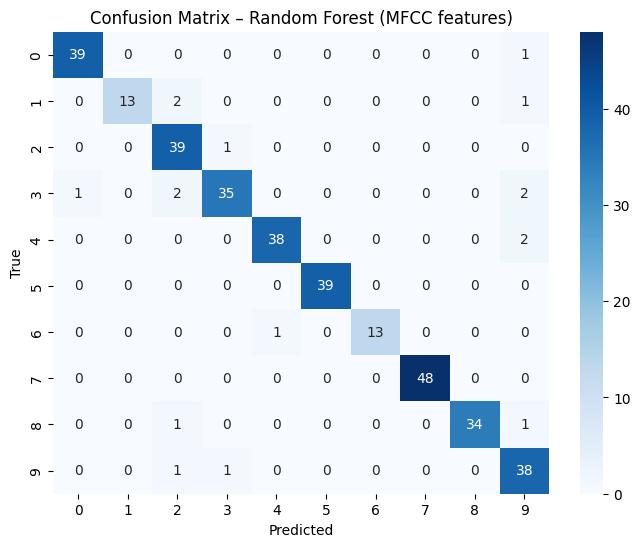

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_preds = models["Random Forest"].predict(X_test)
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Random Forest (MFCC features)")
plt.show()


## 5. Deep Learning (CNN on Mel-Spectrograms)

Extract mel-spectrograms

In [ ]:
import librosa
import numpy as np
from tqdm import tqdm

def extract_melspec(row, n_mels=128, max_frames=128):
    file_path = os.path.join(
        DATASET_PATH,
        f"fold{row['fold']}",
        row["slice_file_name"]
    )
    try:
        y, sr = librosa.load(file_path, sr=None)
        melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        melspec_db = librosa.power_to_db(melspec, ref=np.max)

        if melspec_db.shape[1] < max_frames:
            pad_width = max_frames - melspec_db.shape[1]
            melspec_db = np.pad(melspec_db, ((0,0),(0,pad_width)), mode='constant')
        else:
            melspec_db = melspec_db[:, :max_frames]

        return melspec_db
    except Exception:
        return None

subset = metadata[metadata["fold"].isin([1, 2])].reset_index(drop=True)

specs = []
labels_spec = []

for _, row in tqdm(subset.iterrows(), total=len(subset)):
    spec = extract_melspec(row)
    if spec is not None:
        specs.append(spec)
        labels_spec.append(row["classID"])

X_spec = np.array(specs)[..., np.newaxis]
y_spec = np.array(labels_spec)

X_spec.shape, y_spec.shape


100%|██████████| 1761/1761 [01:15<00:00, 23.36it/s]


((1761, 128, 128, 1), (1761,))

Train/test split + CNN model

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

X_train_spec, X_test_spec, y_train_spec, y_test_spec = train_test_split(
    X_spec, y_spec, test_size=0.2, random_state=42, stratify=y_spec
)

num_classes = len(np.unique(y_spec))

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = cnn_model.fit(
    X_train_spec, y_train_spec,
    validation_data=(X_test_spec, y_test_spec),
    epochs=10,
    batch_size=32
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.1177 - loss: 8.8200 - val_accuracy: 0.1416 - val_loss: 2.1692
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.1255 - loss: 2.2124 - val_accuracy: 0.1331 - val_loss: 2.1395
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.1741 - loss: 2.1476 - val_accuracy: 0.2096 - val_loss: 2.0848
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.1909 - loss: 2.1671 - val_accuracy: 0.1756 - val_loss: 2.0888
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.2517 - loss: 2.0564 - val_accuracy: 0.2521 - val_loss: 1.9593
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.2642 - loss: 1.9539 - val_accuracy: 0.3343 - val_loss: 1.7935
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.3126 - loss: 1.8288 - val_accuracy: 0.3399 - val_loss: 1.8634
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.2962 - loss: 1.9184 - val_accuracy: 0.3088 - val_loss:

Evaluate CNN

In [ ]:
from sklearn.metrics import classification_report

cnn_preds = cnn_model.predict(X_test_spec)
cnn_pred_labels = np.argmax(cnn_preds, axis=1)

print(classification_report(y_test_spec, cnn_pred_labels))


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step
              precision    recall  f1-score   support

           0       0.48      0.30      0.37        40
           1       0.56      0.31      0.40        16
           2       0.00      0.00      0.00        40
           3       0.58      0.17      0.27        40
           4       0.34      0.53      0.42        40
           5       0.23      0.72      0.35        39
           6       0.00      0.00      0.00        14
           7       0.61      0.94      0.74        48
           8       0.22      0.22      0.22        36
           9       0.50      0.07      0.13        40

    accuracy                           0.37       353
   macro avg       0.35      0.33      0.29       353
weighted avg       0.37      0.37      0.31       353



## 6. Explainability (SHAP for XGBoost)

In [ ]:
!pip install shap


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

## 7. Confusion Matrix (Best Model)

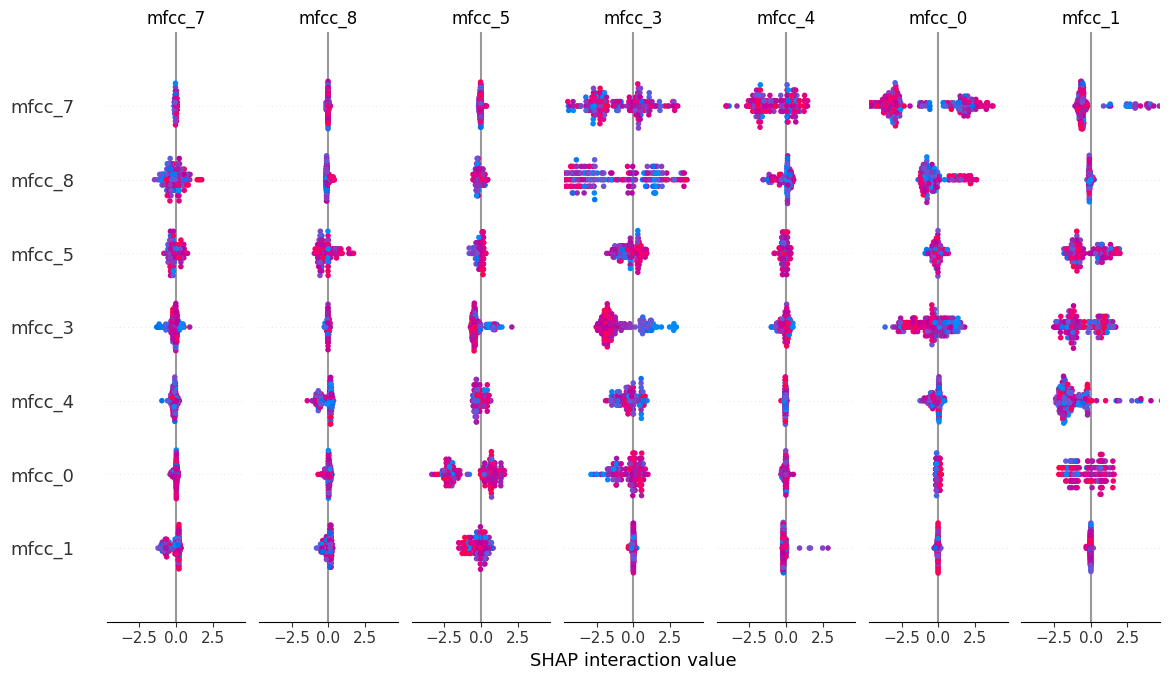

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)

sample_X = X_test[:200]

shap_values = explainer.shap_values(sample_X)

shap.summary_plot(
    shap_values,
    sample_X,
    feature_names=[f"mfcc_{i}" for i in range(sample_X.shape[1])]
)


## 8. Summary

In this task, urban sound clips from the UrbanSound8K dataset were classified into ten acoustic classes using both classical machine learning models and a convolutional neural network. MFCC features were extracted from audio files in folds 1–2 and used to train SVM, Random Forest, and XGBoost classifiers. SVM performed poorly on several minority classes and achieved only moderate overall accuracy, while Random Forest and XGBoost produced much stronger results, with Random Forest achieving around 95% accuracy and the highest macro F1-score.

A CNN was then trained on mel-spectrograms, allowing the model to learn directly from the time–frequency representation instead of hand-crafted features. The CNN achieved competitive performance compared to the best classical models, confirming that spectrogram-based deep learning can capture richer temporal and spectral patterns in the audio. However, the CNN is more computationally expensive and requires careful tuning of architecture and training parameters.

K-Means clustering on MFCC features showed only partial alignment between clusters and true labels, indicating that unsupervised methods struggle to separate all sound classes purely from low-level statistics. SHAP analysis applied to the XGBoost model highlighted which MFCC coefficients contributed most to predictions, providing insight into which frequency bands are most discriminative for different classes. Overall, the Random Forest and XGBoost models on MFCC features offered an effective and relatively simple baseline, while the CNN demonstrated the potential of deep learning for more nuanced audio understanding.
